In [82]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
%matplotlib inline

In [83]:
df = pd.read_csv('insurance.csv')

In [84]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [86]:
# Show the number of missing values by column
missing_counts = df.isnull().sum()
print("Number of missing values by column:")
print(missing_counts)

# We will fill in the missing data 
if missing_counts.sum() > 0:
    numeric_cols = df.select_dtypes(include=["number"]).columns
    categorical_cols = df.select_dtypes(exclude=["number"]).columns

    # Fill numerical columns with the median
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    # We will fill the categorical columns using the mode
    for col in categorical_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])

    print("\nMissing values have been filled in. Current number of missing values:")
    print(df.isnull().sum())
else:
    print("\nThere are no missing values in the dataset.")

Number of missing values by column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

There are no missing values in the dataset.


In [87]:
# Check the number of duplicate records
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate records: {duplicate_count}")

# If there are duplicate records, delete them and print the current number of rows
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate records have been deleted.")
else:
    print("No duplicate records found.")

print(f"Current line count: {df.shape[0]}")

Number of duplicate records: 1
Duplicate records have been deleted.
Current line count: 1337


In [88]:
# Check the minimum values for numeric columns
numeric_cols_to_check = ["age", "bmi", "children", "charges"]
min_values = df[numeric_cols_to_check].min()

print("Minimum values of numeric columns:")
print(min_values)

# Report only negative values
print("\nReport of a logically incorrect value (< 0):")
invalid_found = False

for col in numeric_cols_to_check:
    negative_values = sorted(df.loc[df[col] < 0, col].unique())
    if len(negative_values) > 0:
        invalid_found = True
        print(f"- {col}: {len(negative_values)} There are different negative values -> {negative_values}")

if not invalid_found:
    print("- There are no negative values in the checked columns.")

Minimum values of numeric columns:
age           18.0000
bmi           15.9600
children       0.0000
charges     1121.8739
dtype: float64

Report of a logically incorrect value (< 0):
- There are no negative values in the checked columns.


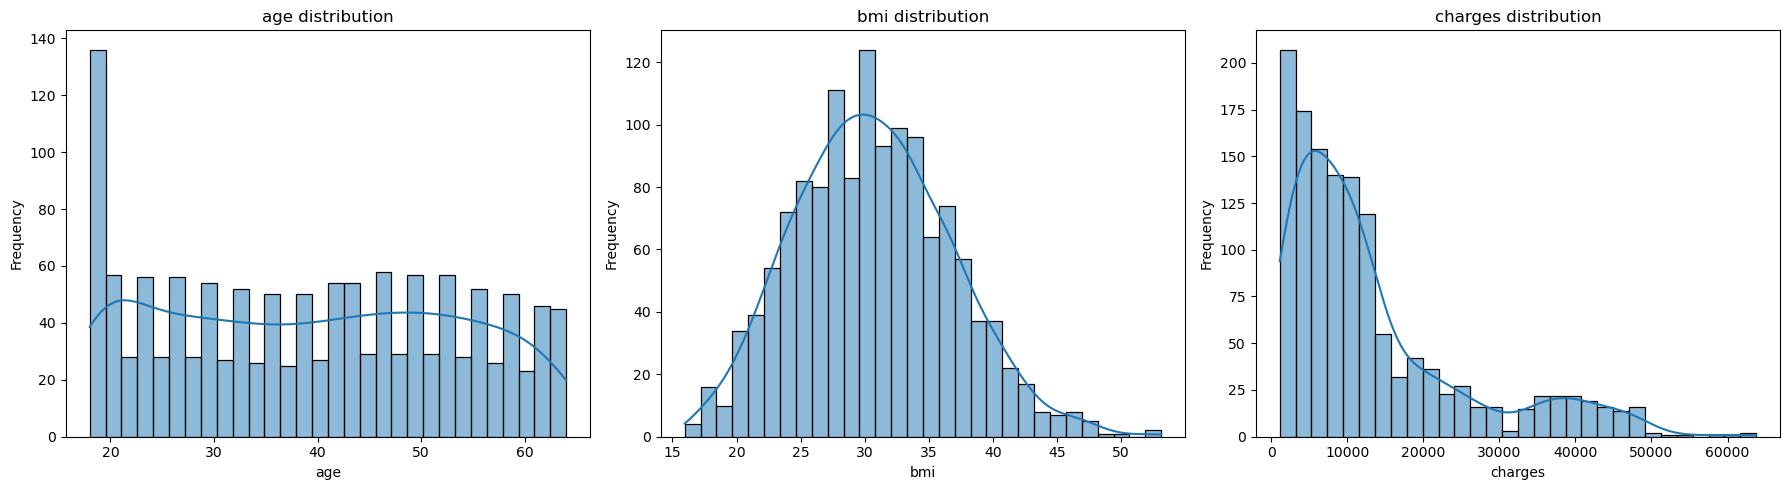

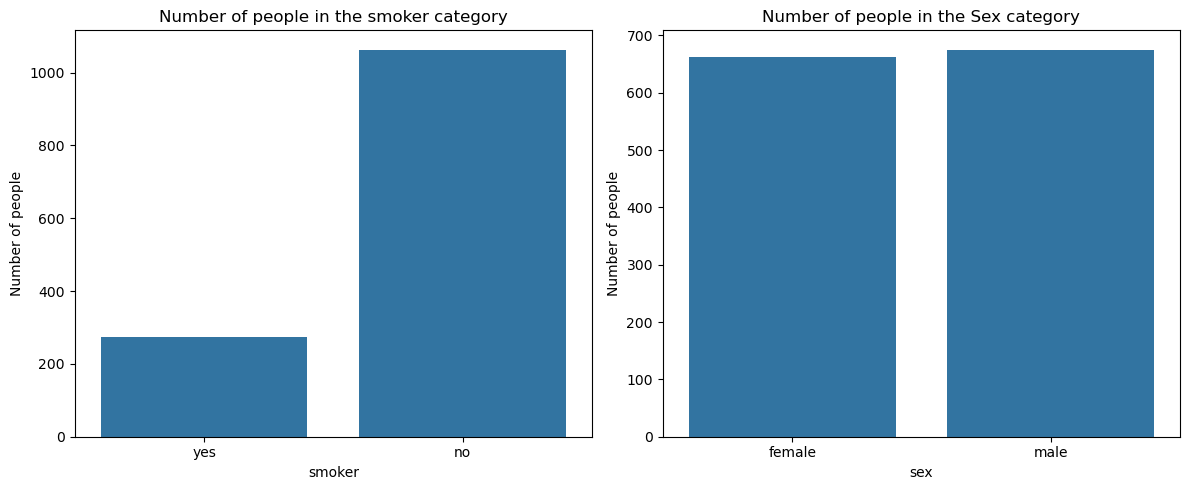

In [89]:
# Side-by-side histograms for numerical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cols = ["age", "bmi", "charges"]
for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f"{col} distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Countplot for Smoker and Sex
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="smoker", ax=axes[0])
axes[0].set_title("Number of people in the smoker category")
axes[0].set_xlabel("smoker")
axes[0].set_ylabel("Number of people")

sns.countplot(data=df, x="sex", ax=axes[1])
axes[1].set_title("Number of people in the Sex category")
axes[1].set_xlabel("sex")
axes[1].set_ylabel("Number of people")

plt.tight_layout()
plt.show()

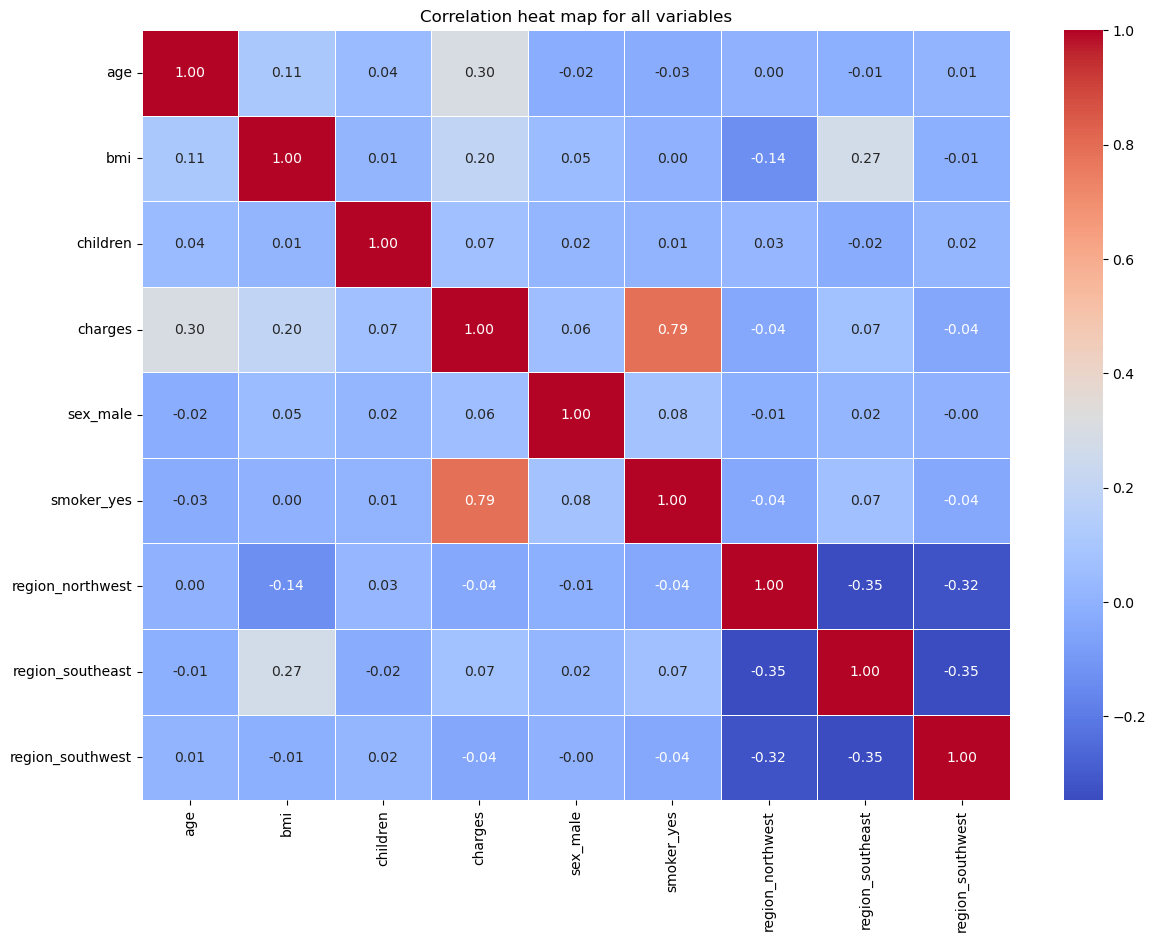

'the feature with the highest correlation with 'charges': smoker_yes
Correlation coefficient: 0.7872


In [90]:
# Temporarily convert categorical columns to numerical values for correlation analysis
corr_df = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

# Correlation matrix
corr_matrix = corr_df.corr(numeric_only=True)

# Heatmap draw
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation heat map for all variables")
plt.show()

# Find the feature with the highest correlation with the charges
charges_corr = corr_matrix["charges"].drop("charges")
max_feature = charges_corr.abs().idxmax()
max_value = charges_corr[max_feature]

print(f"'the feature with the highest correlation with 'charges': {max_feature}")
print(f"Correlation coefficient: {max_value:.4f}")

1. The factor with the highest correlation by far is smoking
2. The factor with the second-highest correlation is age
3. The factor with the third-highest correlation is BMI


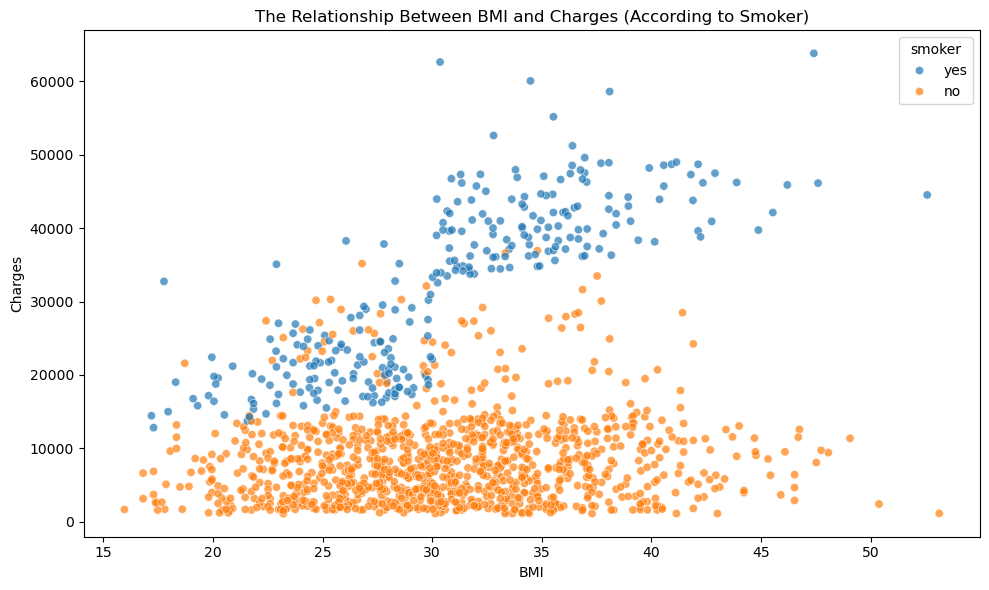

Average charges in the smoker section:
smoker
yes    32050.231832
no      8440.660307
Name: charges, dtype: float64

Correlation between BMI and charges in the smoker subgroup:
smoker     
no      bmi    0.084077
yes     bmi    0.806481
Name: charges, dtype: float64


In [91]:
# The relationship between BMI and charges (by smoking status)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7)
plt.title("The Relationship Between BMI and Charges (According to Smoker)")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.legend(title="smoker")
plt.tight_layout()
plt.show()

# A brief summary to aid interpretation
print("Average charges in the smoker section:")
print(df.groupby("smoker")["charges"].mean().sort_values(ascending=False))

print("\nCorrelation between BMI and charges in the smoker subgroup:")
print(df.groupby("smoker")[["bmi", "charges"]].corr().iloc[0::2, -1])

While the orange dots on the graph (non-smokers) are clustered at the bottom, the blue dots (smokers) have literally skyrocketed. This means that smoking directly increases insurance costs by 2 to 3 times.

Smokers with a BMI under 30 pay between 15,000 and 30,000.

As soon as the BMI exceeds 30, those blue points jump up another notch to the 35,000–60,000 range.
Smokers with a BMI under 30 pay between 15,000 and 30,000.

As soon as the BMI exceeds 30, those blue points jump up another notch to the 35,000–60,000 range.

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [ ]:
# A more secure conversion process (suitable for re-execution)

# A fresh start every time
df = pd.read_csv("insurance.csv")

# sex ve smoker -> LabelEncoder (0/1)
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
df["sex"] = le_sex.fit_transform(df["sex"])
df["smoker"] = le_smoker.fit_transform(df["smoker"])

# region -> One-Hot Encoding
# When `dtype=int` is used, 0 and 1 are produced instead of True and False
df = pd.get_dummies(df, columns=["region"], drop_first=True, dtype=int)

# Control
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [94]:
# Start with the raw data, convert all categorical variables to numerical values, then scale them


df = pd.read_csv("insurance.csv")

# Convert the ‘sex’ and ‘smoker’ columns using LabelEncoder
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
df["sex"] = le_sex.fit_transform(df["sex"])
df["smoker"] = le_smoker.fit_transform(df["smoker"])

# Convert the ‘region’ column using One-Hot Encoding (drop_first=True)
df = pd.get_dummies(df, columns=["region"], drop_first=True)


X = df.drop("charges", axis=1)
y = df["charges"]

# StandardScaler use
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,-1.438764,-1.010519,-0.453320,-0.908614,1.970587,-0.566418,-0.611324,1.765481
1,-1.509965,0.989591,0.509621,-0.078767,-0.507463,-0.566418,1.635795,-0.566418
2,-0.797954,0.989591,0.383307,1.580926,-0.507463,-0.566418,1.635795,-0.566418
3,-0.441948,0.989591,-1.305531,-0.908614,-0.507463,1.765481,-0.611324,-0.566418
4,-0.513149,0.989591,-0.292556,-0.908614,-0.507463,1.765481,-0.611324,-0.566418


In [ ]:

X = df.drop("charges", axis=1)
y = df["charges"]

# Scaling X data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,-1.438764,-1.010519,-0.453320,-0.908614,1.970587,-0.566418,-0.611324,1.765481
1,-1.509965,0.989591,0.509621,-0.078767,-0.507463,-0.566418,1.635795,-0.566418
2,-0.797954,0.989591,0.383307,1.580926,-0.507463,-0.566418,1.635795,-0.566418
3,-0.441948,0.989591,-1.305531,-0.908614,-0.507463,1.765481,-0.611324,-0.566418
4,-0.513149,0.989591,-0.292556,-0.908614,-0.507463,1.765481,-0.611324,-0.566418


In [ ]:
# Split the data into training (80%) and test (20%) sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1070, 8)
X_test shape: (268, 8)
y_train shape: (1070,)
y_test shape: (268,)


In [ ]:
# Create, train, and make predictions with the RandomForestRegressor model

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("The model was trained and predictions were generated for the test data.")
print("Top 5 predictions:", y_pred[:5])

Model eğitildi ve test verisi için tahminler üretildi.
İlk 5 tahmin: [ 9627.2160164  5570.1966765 28239.6470855 12462.6824866 34640.8607121]


R2 Score: 0.8650
Mean Absolute Error (MAE): 2550.6702


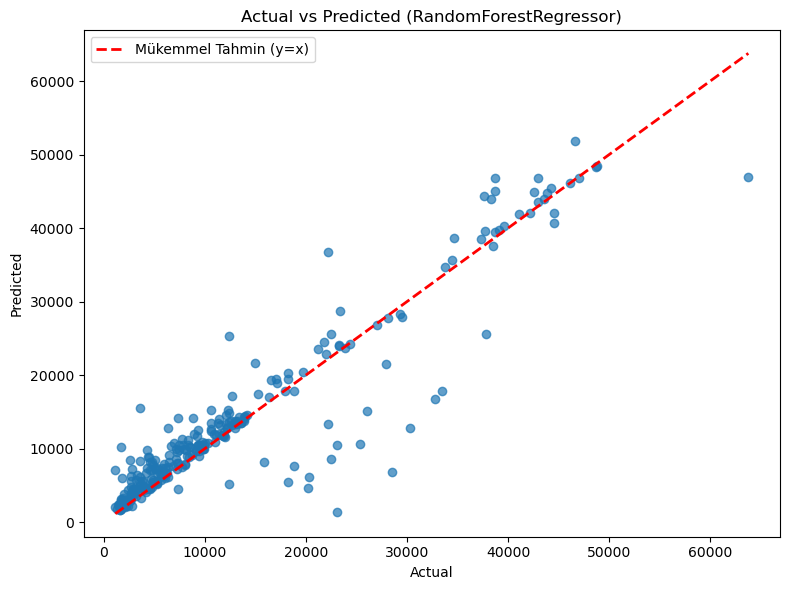

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R2 Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

# The best-fit line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect Prediction (y=x)")

plt.title("Actual vs Predicted (RandomForestRegressor)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Manuel test verisi oluşturuyoruz ve charges tahmini yapacağız
# Özellikler: age=30, sex=1 (male), bmi=35, children=2, smoker=1 (yes), region=northwest
manual_test = {col: 0 for col in X.columns}
manual_test["age"] = 30
manual_test["sex"] = 1
manual_test["bmi"] = 35
manual_test["children"] = 2
manual_test["smoker"] = 1

# One-Hot encoding setting (compatible with the `drop_first=True` configuration)
if "region_northwest" in manual_test:
    manual_test["region_northwest"] = 1
if "region_southeast" in manual_test:
    manual_test["region_southeast"] = 0
if "region_southwest" in manual_test:
    manual_test["region_southwest"] = 0

manual_df = pd.DataFrame([manual_test], columns=X.columns)
manual_pred = rf_model.predict(manual_df)[0]

print(f"Predicted insurance charge: {manual_pred:.2f}")

Predicted insurance charge: 39690.05


In [ ]:
# Hyperparameter optimization using RandomizedSearchCV and RandomForestRegressor
# Parameter distributions (especially n_estimators and max_depth)
param_dist = {
    "n_estimators": [100, 200, 300, 500, 700, 1000],
    "max_depth": [None, 5, 10, 15, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_base = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)
print(f"The Best CV R2 score: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
En iyi parametreler:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 5}
En iyi CV R2 skoru: 0.8452


In [ ]:
import pickle

# If the scaler does not yet exist or is not fitted, fit it using X
if "scaler" not in globals():
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler().fit(X)

with open("insurance_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("insurance_model.pkl and scaler.pkl have been saved.")

insurance_model.pkl ve scaler.pkl kaydedildi.
